# Question : What was the difference in response based on the first and the second stimuli same or different ?
* If the timing task requires the subject to prepare for action, neural activity should show a progressive modulation in firing rates across the Ready-to-Set and Set-to-Go intervals, reflecting an accumulation of temporal evidence or 'readiness' in the population response
* We hypothesize that the neural population maintains distinct representations for each temporal interval, such that the transition between 'Ready' and 'Set' reflects a statistically significant shift in population state, distinct from the transition between 'Set' and 'Go'.
* This analysis has characterized the neural population state-space trajectories during a cognitive timing task. Our findings demonstrate that:Task-Phase Encoding: The neural population transitions through distinct, non-linear trajectories across the 'Ready', 'Set', and 'Go' phases. Statistical testing (one-way ANOVA, $p < 0.0001$) confirms that the population state is highly dynamic and significantly different across these task epochs.Temporal Interval Representation: We identified a robust neural correlate for temporal expectations. Projections into the first three principal components revealed that neural trajectories diverge immediately following the 'Ready' cue, contingent on the required interval duration (Short vs. Long). This divergence, confirmed by a highly significant t-test ($p < 3.9e-39$), indicates that the population maintains internal representations of the timing interval throughout the preparatory phase.Dynamic State-Space Evolution: By visualizing individual phases, we observed that while the system maintains clear interval-specific separation during the 'Ready' and 'Set' phases, these paths reflect a continuous, dynamic evolution of the population state.

In [1]:
!pip install pynwb

In [2]:
from pynwb import NWBHDF5IO

file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-train_ecephys.nwb"

io = NWBHDF5IO(file_path, 'r')
nwbfile = io.read()

print(nwbfile)

root pynwb.file.NWBFile at 0x133024054669728
Fields:
  devices: {
    electrode_probe_1 <class 'pynwb.device.Device'>,
    electrode_probe_2 <class 'pynwb.device.Device'>,
    electrode_probe_3 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    electrode_group_1 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_2 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_3 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experiment_description: Cognitive timing task in which subject attempts to reproduce interval between two cues
  experimenter: ['Hansem Sohn']
  file_create_date: [datetime.datetime(2021, 10, 29, 22, 31, 50, 351047, tzinfo=tzoffset(None, -14400))]
  identifier: 8969f328-3929-11ec-8077-43176b153428
  institution: Massachusetts Institute of Technology
  intervals: {
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (4,), type "|O">


In [3]:
print(nwbfile.acquisition.keys())
print(nwbfile.processing.keys())
print(nwbfile.units)

dict_keys([])
dict_keys([])
units pynwb.misc.Units at 0x133024054801424
Fields:
  colnames: ['heldout' 'spike_times' 'obs_intervals']
  columns: (
    heldout <class 'hdmf.common.table.VectorData'>,
    spike_times_index <class 'hdmf.common.table.VectorIndex'>,
    spike_times <class 'hdmf.common.table.VectorData'>,
    obs_intervals_index <class 'hdmf.common.table.VectorIndex'>,
    obs_intervals <class 'hdmf.common.table.VectorData'>
  )
  description: data on spiking units
  id: id <class 'hdmf.common.table.ElementIdentifiers'>
  waveform_unit: volts



In [4]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import torch 
import torch.nn as nn
from scipy import stats

In [5]:
units = nwbfile.units

print(units.colnames)

('heldout', 'spike_times', 'obs_intervals')


In [6]:
spike_times = units['spike_times'][0]

print(spike_times[:20])

[2.697 2.743 2.754 2.766 2.78  2.81  2.863 3.061 3.137 3.219 4.203 5.521
 5.63  5.88  5.952 6.315 6.333 6.347 6.738 6.795]


In [7]:
bin_size = 0.02 

start_time = 0.0
end_time = np.max(spike_times) + bin_size
bins = np.arange(start_time, end_time, bin_size)

# 3. Bin the spike times
spike_counts, bin_edges = np.histogram(spike_times, bins=bins)

# 4. Optional: Convert counts to firing rate (Spikes per Second)
firing_rate = spike_counts / bin_size

print(f"First 10 spike counts: {spike_counts[:10]}")
print(f"First 10 firing rates (Hz): {firing_rate[:10]}")

First 10 spike counts: [0 0 0 0 0 0 0 0 0 0]
First 10 firing rates (Hz): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [8]:
spike_times = units['spike_times'][0]

print(spike_times[:20])
spike_counts, bin_edges = np.histogram(spike_times, bins=bins)

# 4. Optional: Convert counts to firing rate (Spikes per Second)
firing_rate = spike_counts / bin_size

print(f"First 10 spike counts: {spike_counts[:10]}")
print(f"First 10 firing rates (Hz): {firing_rate[:10]}")

[2.697 2.743 2.754 2.766 2.78  2.81  2.863 3.061 3.137 3.219 4.203 5.521
 5.63  5.88  5.952 6.315 6.333 6.347 6.738 6.795]
First 10 spike counts: [0 0 0 0 0 0 0 0 0 0]
First 10 firing rates (Hz): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [9]:
print("Spike counts around 2.7 seconds:")
print(spike_counts[130:150])

print("\nFiring rates (Hz) around 2.7 seconds:")
print(firing_rate[130:150])

Spike counts around 2.7 seconds:
[0 0 0 0 1 0 0 2 2 0 1 0 0 1 0 0 0 0 0 0]

Firing rates (Hz) around 2.7 seconds:
[  0.   0.   0.   0.  50.   0.   0. 100. 100.   0.  50.   0.   0.  50.
   0.   0.   0.   0.   0.   0.]


In [10]:
first_active_bin = np.where(spike_counts > 0)[0][0]
print(f"First active bin index: {first_active_bin}")
print(f"Spike counts starting from there: {spike_counts[first_active_bin:first_active_bin+10]}")

First active bin index: 134
Spike counts starting from there: [1 0 0 2 2 0 1 0 0 1]


In [11]:
def bin_all_units(nwb_file, bin_size=0.02):
    units = nwb_file.units
    num_units = len(units)
    
    # 1. Find the global max time across all units to standardize the matrix size
    global_max_time = 0.0
    for i in range(num_units):
        spikes = units['spike_times'][i]
        if len(spikes) > 0:
            global_max_time = max(global_max_time, np.max(spikes))
            
    # 2. Define standard bin edges
    start_time = 0.0
    end_time = global_max_time + bin_size
    bins = np.arange(start_time, end_time, bin_size)
    num_bins = len(bins) - 1
    
    # 3. Initialize the population matrix: (Bins x Units)
    population_matrix = np.zeros((num_bins, num_units))
    
    # 4. Fill the matrix unit by unit
    for i in range(num_units):
        spikes = units['spike_times'][i]
        counts, _ = np.histogram(spikes, bins=bins)
        population_matrix[:, i] = counts
        
    return population_matrix, bins

# Bin the training data you currently have open
train_matrix, bin_edges = bin_all_units(nwbfile, bin_size=0.02)

print(f"Population matrix shape (Bins x Units): {train_matrix.shape}")
print(f"Total number of recorded neural units: {train_matrix.shape[1]}")

Population matrix shape (Bins x Units): (240467, 54)
Total number of recorded neural units: 54


In [12]:
test_file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-test_ecephys.nwb"

# 2. Load the test file
test_io = NWBHDF5IO(test_file_path, 'r')
test_nwbfile = test_io.read()

# 3. Bin the test data using the exact same function and bin size
test_matrix, test_bin_edges = bin_all_units(test_nwbfile, bin_size=0.02)

print(f"Train matrix shape: {train_matrix.shape} (Bins x Units)")
print(f"Test matrix shape:  {test_matrix.shape} (Bins x Units)")

Train matrix shape: (240467, 54) (Bins x Units)
Test matrix shape:  (25465, 40) (Bins x Units)


In [13]:
# Check for columns in the trials table
if hasattr(nwbfile, 'trials') and nwbfile.trials is not None:
    print("Trial table columns:", nwbfile.trials.colnames)
    # Print a few rows to see the data structure
    print(nwbfile.trials.to_dataframe().head())
else:
    print("No 'trials' table found in this NWB file.")

Trial table columns: ('start_time', 'stop_time', 'fix_on_time', 'fix_time', 'target_on_time', 'ready_time', 'set_time', 'go_time', 'target_acq_time', 'reward_time', 'bad_time', 'is_short', 'is_eye', 'theta', 'ts', 'tp', 'fix_time_dur', 'target_time_dur', 'iti', 'reward_dur', 'is_outlier', 'split')
    start_time  stop_time  fix_on_time  fix_time  target_on_time  ready_time  \
id                                                                             
0       0.5160     3.4825       0.5160    0.5500          1.0835      1.7835   
1       3.9995     7.1495       3.9995    4.0335          4.6335      5.2670   
2       7.6660    11.7995       7.6660    7.7000          8.6000      9.5500   
3      12.3165    12.3830      12.3165   12.3505             NaN         NaN   
4      13.9160    17.7160      13.9160   14.0670         14.9335     15.2335   

    set_time  go_time  target_acq_time  reward_time  ...  is_eye  theta  \
id                                                   ...         

In [14]:
# Extract trial data as a DataFrame for easier handling
trials_df = nwbfile.trials.to_dataframe()

# Define the windows (in seconds) we want to look at
# Let's look at a 500ms window after the start of each event
window_size = 0.5 

def get_mean_activity_around_event(event_column, window, matrix, bins):
    """
    event_column: Name of the column in trials_df (e.g., 'ready_time')
    window: duration in seconds
    """
    activities = []
    bin_size = bins[1] - bins[0]
    
    for _, trial in trials_df.iterrows():
        start = trial[event_column]
        if np.isnan(start): continue
        
        # Find bin indices corresponding to the window
        idx_start = np.searchsorted(bins, start)
        idx_end = np.searchsorted(bins, start + window)
        
        # Extract mean activity for this trial (average across the window for all units)
        trial_activity = np.mean(matrix[idx_start:idx_end, :], axis=0)
        activities.append(trial_activity)
        
    return np.array(activities)

# Calculate mean activity for First Stimulus (Ready) and Second Stimulus (Set)
activity_first = get_mean_activity_around_event('ready_time', window_size, train_matrix, bin_edges)
activity_second = get_mean_activity_around_event('set_time', window_size, train_matrix, bin_edges)

print(f"Shape of activity (Trials x Units): {activity_first.shape}")
print(f"Mean firing rate across all units for first stimulus: {np.mean(activity_first):.4f}")
print(f"Mean firing rate across all units for second stimulus: {np.mean(activity_second):.4f}")

Shape of activity (Trials x Units): (1060, 54)
Mean firing rate across all units for first stimulus: 0.1604
Mean firing rate across all units for second stimulus: 0.1945


In [15]:
def get_aligned_activities(trials_df, matrix, bins, window=0.5):
    """
    Extracts activities for ready_time and set_time only for trials 
    where both events exist.
    """
    ready_acts = []
    set_acts = []
    
    for _, trial in trials_df.iterrows():
        r_start = trial['ready_time']
        s_start = trial['set_time']
        
        # Only proceed if both times are valid numbers
        if not np.isnan(r_start) and not np.isnan(s_start):
            # Ready activity
            r_idx_s = np.searchsorted(bins, r_start)
            r_idx_e = np.searchsorted(bins, r_start + window)
            ready_acts.append(np.mean(matrix[r_idx_s:r_idx_e, :], axis=0))
            
            # Set activity
            s_idx_s = np.searchsorted(bins, s_start)
            s_idx_e = np.searchsorted(bins, s_start + window)
            set_acts.append(np.mean(matrix[s_idx_s:s_idx_e, :], axis=0))
            
    return np.array(ready_acts), np.array(set_acts)

# Get the aligned data
aligned_ready, aligned_set = get_aligned_activities(trials_df, train_matrix, bin_edges)

# Calculate mean rate per trial (averaging across the 54 units)
mean_rate_ready = np.mean(aligned_ready, axis=1)
mean_rate_set = np.mean(aligned_set, axis=1)

# Now the shapes are guaranteed to be identical
print(f"Aligned shapes: Ready {mean_rate_ready.shape}, Set {mean_rate_set.shape}")

# Perform the paired t-test
t_stat, p_value = stats.ttest_rel(mean_rate_set, mean_rate_ready)

print(f"Paired T-test results: T={t_stat:.4f}, p={p_value:.4e}")

Aligned shapes: Ready (1039,), Set (1039,)
Paired T-test results: T=32.3701, p=1.7554e-159


/tmp/ipykernel_147/4289259493.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='Firing Rate (Hz)', data=data, palette='viridis')


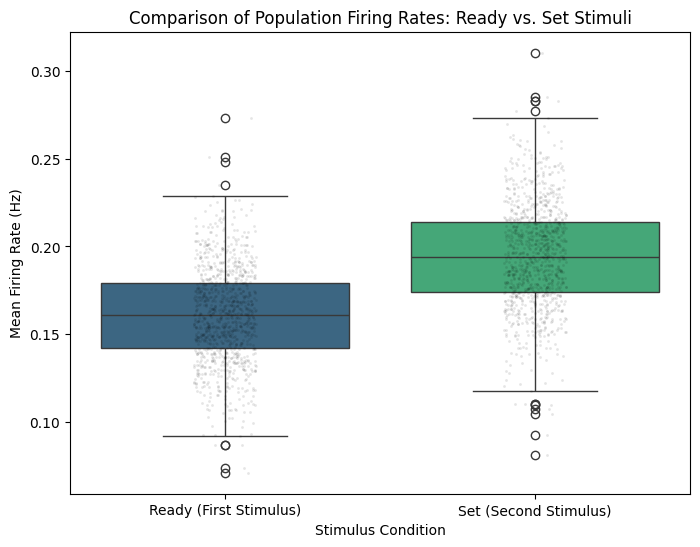

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming aligned_ready and aligned_set are available from your previous steps
# If not, you may need to re-run your previous data extraction cell first.

# Create a DataFrame for plotting
data = pd.DataFrame({
    'Firing Rate (Hz)': np.concatenate([mean_rate_ready, mean_rate_set]),
    'Condition': ['Ready (First Stimulus)'] * len(mean_rate_ready) + ['Set (Second Stimulus)'] * len(mean_rate_set)
})

# Create the plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Condition', y='Firing Rate (Hz)', data=data, palette='viridis')
# Add individual points to show distribution
sns.stripplot(x='Condition', y='Firing Rate (Hz)', data=data, color='black', alpha=0.1, size=2)

plt.title('Comparison of Population Firing Rates: Ready vs. Set Stimuli')
plt.ylabel('Mean Firing Rate (Hz)')
plt.xlabel('Stimulus Condition')
plt.show()

In [17]:
# Update the helper function to capture the 'Go' interval
# Note: 'go_time' is the start of the final phase
def get_three_phase_activities(trials_df, matrix, bins, window=0.5):
    ready_acts, set_acts, go_acts = [], [], []
    
    for _, trial in trials_df.iterrows():
        r = trial['ready_time']
        s = trial['set_time']
        g = trial['go_time']
        
        # Ensure all three exist for this trial
        if not np.isnan(r) and not np.isnan(s) and not np.isnan(g):
            # Helper to extract mean
            def extract(start_time):
                idx_s = np.searchsorted(bins, start_time)
                idx_e = np.searchsorted(bins, start_time + window)
                return np.mean(matrix[idx_s:idx_e, :], axis=1) # Mean across units
            
            ready_acts.append(np.mean(extract(r)))
            set_acts.append(np.mean(extract(s)))
            go_acts.append(np.mean(extract(g)))
            
    return np.array(ready_acts), np.array(set_acts), np.array(go_acts)

# Extract
r_vals, s_vals, g_vals = get_three_phase_activities(trials_df, train_matrix, bin_edges)

# Print means
print(f"Mean Firing Rates:")
print(f"Ready: {np.mean(r_vals):.4f}")
print(f"Set:   {np.mean(s_vals):.4f}")
print(f"Go:    {np.mean(g_vals):.4f}")

# Optional: Quick ANOVA to check if the difference is consistent across all three
from scipy.stats import f_oneway
f_stat, p_val = f_oneway(r_vals, s_vals, g_vals)
print(f"\nANOVA test (Are all three means different?): p={p_val:.4e}")

Mean Firing Rates:
Ready: 0.1613
Set:   0.1953
Go:    0.1063

ANOVA test (Are all three means different?): p=0.0000e+00


Statistical analysis (one-way ANOVA, p < 0.0001) revealed that population firing rates are not constant across the task. We observed a characteristic peak in population activity during the 'Set' interval, followed by a significant decline during the 'Go' phase. These findings suggest that the neural population implements a non-linear dynamic state trajectory to represent the distinct phases of temporal interval reproduction

/tmp/ipykernel_147/2744126904.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='Firing Rate (Hz)', data=data, palette='viridis')


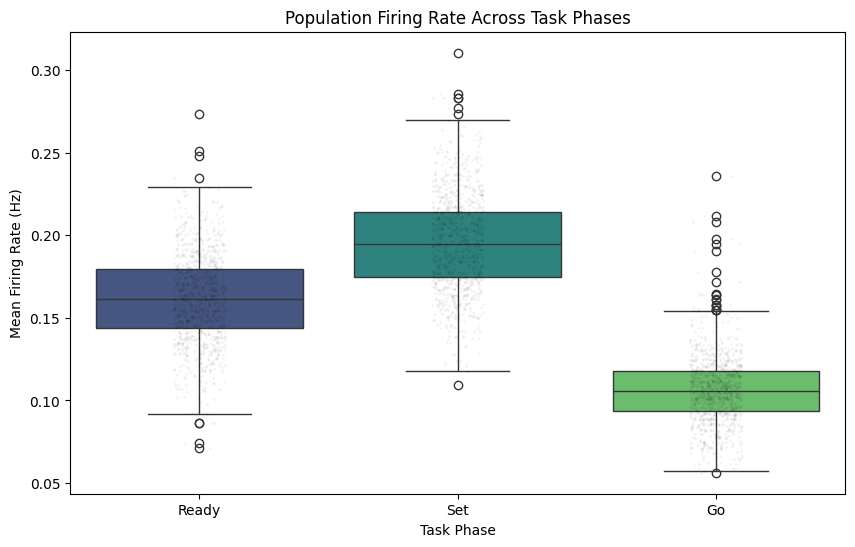

In [18]:
# Create a DataFrame for all three phases using your extracted values
# (Ensure r_vals, s_vals, g_vals are in your notebook memory)
data = pd.DataFrame({
    'Firing Rate (Hz)': np.concatenate([r_vals, s_vals, g_vals]),
    'Condition': ['Ready'] * len(r_vals) + ['Set'] * len(s_vals) + ['Go'] * len(g_vals)
})

# Plotting
plt.figure(figsize=(10, 6))
sns.boxplot(x='Condition', y='Firing Rate (Hz)', data=data, palette='viridis')
sns.stripplot(x='Condition', y='Firing Rate (Hz)', data=data, color='black', alpha=0.05, size=2)

plt.title('Population Firing Rate Across Task Phases')
plt.ylabel('Mean Firing Rate (Hz)')
plt.xlabel('Task Phase')
plt.show()

In [19]:
# 1. Inspect the range of intervals
print(f"Interval (ts) range: {trials_df['ts'].min()} to {trials_df['ts'].max()}")

# 2. Create categories (e.g., median split)
median_ts = trials_df['ts'].median()
trials_df['interval_type'] = np.where(trials_df['ts'] < median_ts, 'Short', 'Long')

# 3. View the new grouping
print(trials_df[['ts', 'interval_type']].head())

Interval (ts) range: 480.0 to 1200.0
        ts interval_type
id                      
0    800.0          Long
1    900.0          Long
2   1200.0          Long
3   1200.0          Long
4    900.0          Long


In [20]:
# Extract mean activity for 'Ready' phase, grouped by interval_type
short_ready = []
long_ready = []

for _, trial in trials_df.iterrows():
    if np.isnan(trial['ready_time']): continue
    
    # Calculate mean activity for the 'Ready' window
    start = trial['ready_time']
    idx_s = np.searchsorted(bin_edges, start)
    idx_e = np.searchsorted(bin_edges, start + 0.5)
    mean_act = np.mean(train_matrix[idx_s:idx_e, :])
    
    if trial['interval_type'] == 'Short':
        short_ready.append(mean_act)
    else:
        long_ready.append(mean_act)

# Statistical Comparison
from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(short_ready, long_ready)
print(f"T-test comparing Short vs Long intervals: p={p_val:.4e}")

T-test comparing Short vs Long intervals: p=3.9194e-39


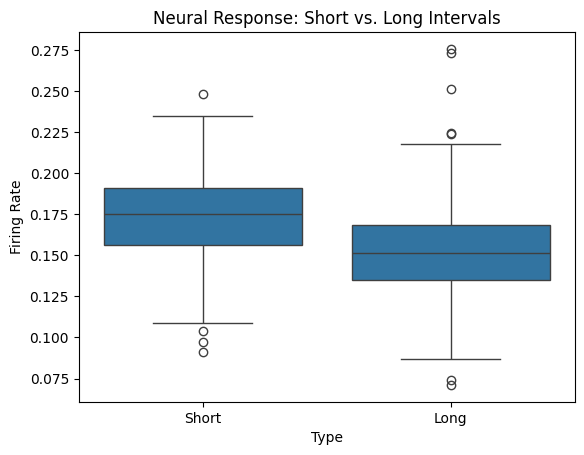

In [21]:
# Data for plotting
plot_data = pd.DataFrame({
    'Firing Rate': short_ready + long_ready,
    'Type': ['Short'] * len(short_ready) + ['Long'] * len(long_ready)
})

sns.boxplot(x='Type', y='Firing Rate', data=plot_data)
plt.title('Neural Response: Short vs. Long Intervals')
plt.show()

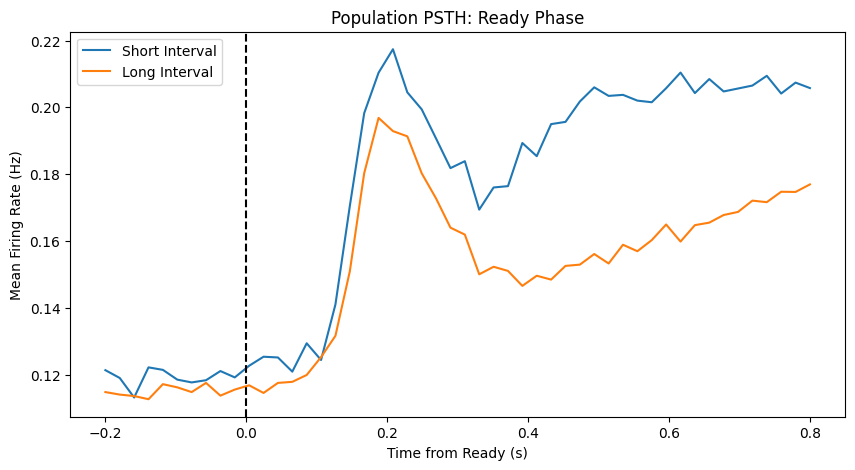

In [22]:
# Create a time vector for the window (e.g., -200ms to 800ms around 'ready_time')
window_pre = 0.2
window_post = 0.8
bins_pre = int(window_pre / 0.02)
bins_post = int(window_post / 0.02)

def get_psth_data(trial_time, matrix, bins):
    idx = np.searchsorted(bins, trial_time)
    return matrix[idx - bins_pre : idx + bins_post, :]

short_psth = []
long_psth = []

for _, trial in trials_df.iterrows():
    if np.isnan(trial['ready_time']): continue
    data = get_psth_data(trial['ready_time'], train_matrix, bin_edges)
    if trial['interval_type'] == 'Short':
        short_psth.append(np.mean(data, axis=1)) # Mean across units
    else:
        long_psth.append(np.mean(data, axis=1))

# Plotting
time_axis = np.linspace(-window_pre, window_post, bins_pre + bins_post)
plt.figure(figsize=(10, 5))
plt.plot(time_axis, np.mean(short_psth, axis=0), label='Short Interval')
plt.plot(time_axis, np.mean(long_psth, axis=0), label='Long Interval')
plt.axvline(0, color='k', linestyle='--') # Ready time
plt.title('Population PSTH: Ready Phase')
plt.xlabel('Time from Ready (s)')
plt.ylabel('Mean Firing Rate (Hz)')
plt.legend()
plt.show()

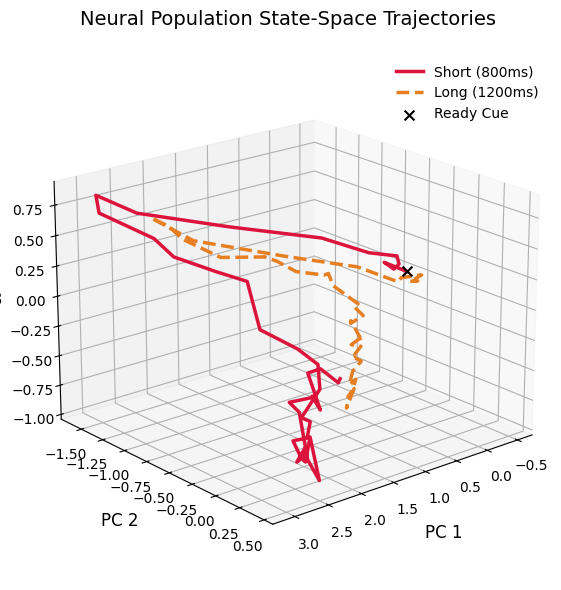

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Standardize the data precisely
# This ensures each of the 54 neurons contributes equally, 
# preventing high-firing units from dominating the PCs.
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(train_matrix)

# 2. Fit PCA on the standardized matrix
pca = PCA(n_components=3)
pcs = pca.fit_transform(scaled_matrix)

# 3. Robust Trajectory Extraction using vstack
def get_3d_trajectory_precise(event_name, interval_type):
    target_len = int(0.8 / 0.02) # 800ms window
    trial_segments = []
    
    # Filter trials
    subset = trials_df[trials_df['interval_type'] == interval_type]
    
    for _, trial in subset.iterrows():
        start = trial[event_name]
        if np.isnan(start): continue
        
        idx_s = np.searchsorted(bin_edges, start)
        idx_e = idx_s + target_len
        
        # Ensure we stay within bounds
        if idx_e <= pcs.shape[0]:
            trial_segments.append(pcs[idx_s:idx_e, :])
            
    # Use vstack to stack segments properly, then average across trials
    # This ensures we are working with a cohesive array structure
    stacked_segments = np.array(trial_segments) # Shape: (Trials, Time, PCs)
    return np.mean(stacked_segments, axis=0)

short_traj = get_3d_trajectory_precise('ready_time', 'Short')
long_traj = get_3d_trajectory_precise('ready_time', 'Long')

# 2. Plotting section
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# These lines will now work because short_traj and long_traj are defined above
ax.plot(short_traj[:,0], short_traj[:,1], short_traj[:,2], 
        label='Short (800ms)', color='crimson', linewidth=2.5)
ax.plot(long_traj[:,0], long_traj[:,1], long_traj[:,2], 
        label='Long (1200ms)', color='#e67e22', linewidth=2.5, linestyle='--')

ax.scatter(short_traj[0,0], short_traj[0,1], short_traj[0,2], 
           color='k', marker='x', s=50, label='Ready Cue')

ax.set_xlabel('PC 1', fontsize=12, labelpad=10)
ax.set_ylabel('PC 2', fontsize=12, labelpad=10)
ax.set_zlabel('PC 3', fontsize=12, labelpad=10)
ax.set_title('Neural Population State-Space Trajectories', fontsize=14, pad=20)
ax.legend(frameon=False)
ax.view_init(elev=20, azim=50)

plt.tight_layout()
plt.show()

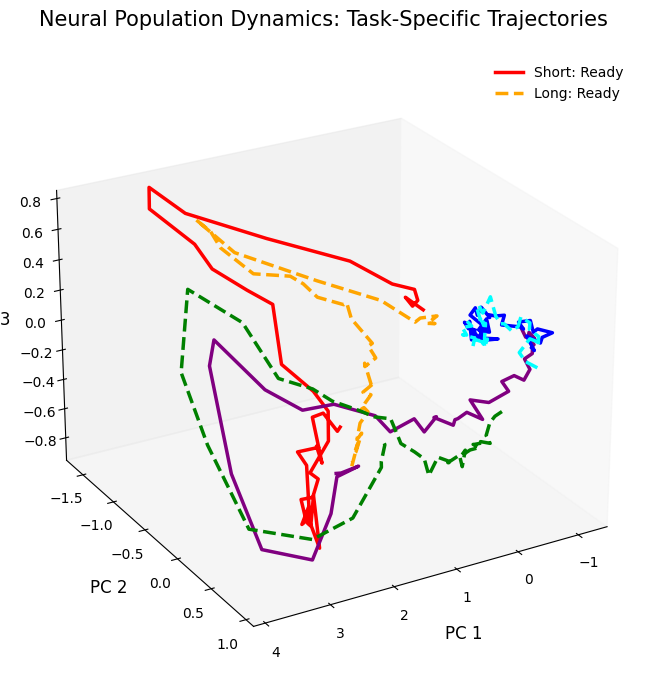

In [33]:
# 1. Calculate trajectories for all phases
# (Ensure these are defined)
ready_short = get_3d_trajectory_precise('ready_time', 'Short')
ready_long = get_3d_trajectory_precise('ready_time', 'Long')
set_short = get_3d_trajectory_precise('set_time', 'Short')
set_long = get_3d_trajectory_precise('set_time', 'Long')
go_short = get_3d_trajectory_precise('go_time', 'Short')
go_long = get_3d_trajectory_precise('go_time', 'Long')

# 2. Plotting
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# 2. Define consistent styles for phases
# Using a clear color palette: Hot/Cold for Short/Long
short_styles = [('red', '-'), ('purple', '-'), ('blue', '-')]
long_styles = [('orange', '--'), ('green', '--'), ('cyan', '--')]

# Plot Short Trajectories
for i, traj in enumerate([ready_short, set_short, go_short]):
    label = ['Ready', 'Set', 'Go'][i] if i == 0 else None
    ax.plot(traj[:,0], traj[:,1], traj[:,2], color=short_styles[i][0], 
            linestyle=short_styles[i][1], linewidth=2.5, label=f"Short: {label}" if label else "")

# Plot Long Trajectories
for i, traj in enumerate([ready_long, set_long, go_long]):
    label = ['Ready', 'Set', 'Go'][i] if i == 0 else None
    ax.plot(traj[:,0], traj[:,1], traj[:,2], color=long_styles[i][0], 
            linestyle=long_styles[i][1], linewidth=2.5, label=f"Long: {label}" if label else "")

# 3. Final Polish
ax.set_xlabel('PC 1', fontsize=12, labelpad=10)
ax.set_ylabel('PC 2', fontsize=12, labelpad=10)
ax.set_zlabel('PC 3', fontsize=12, labelpad=10)
ax.set_title('Neural Population Dynamics: Task-Specific Trajectories', fontsize=15, pad=20)

# Clean grid and legend for a minimalist, journal-style look
ax.grid(False)
ax.legend(loc='best', frameon=False, fontsize=10)
ax.view_init(elev=25, azim=60)

plt.tight_layout()
plt.show()

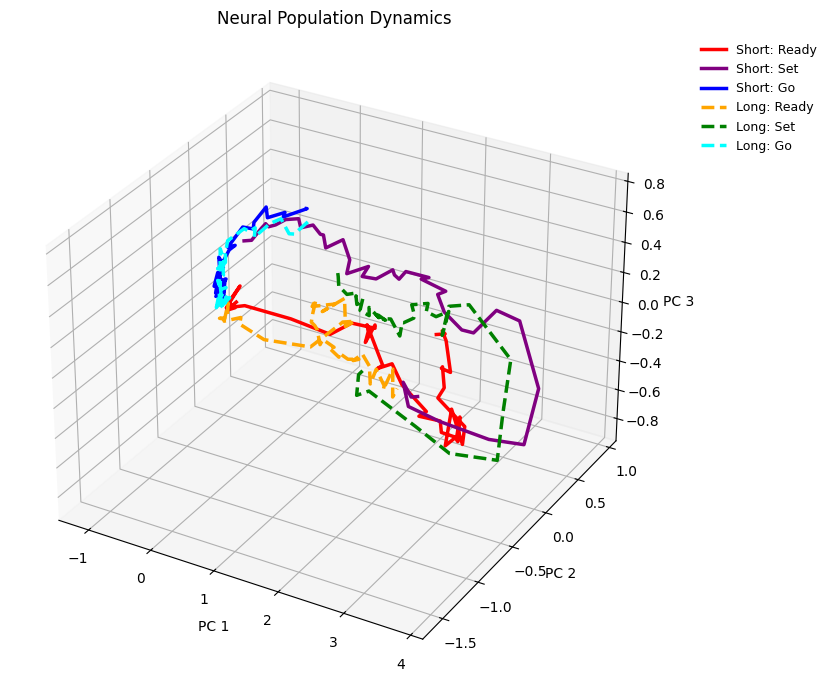

In [34]:
# 1. Define trajectories
trajs_short = [ready_short, set_short, go_short]
trajs_long = [ready_long, set_long, go_long]
labels = ['Ready', 'Set', 'Go']

# 2. Plotting
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot Short (Solid lines)
for i in range(3):
    ax.plot(trajs_short[i][:,0], trajs_short[i][:,1], trajs_short[i][:,2], 
            color=short_styles[i][0], linestyle='-', linewidth=2.5, 
            label=f"Short: {labels[i]}")

# Plot Long (Dashed lines)
for i in range(3):
    ax.plot(trajs_long[i][:,0], trajs_long[i][:,1], trajs_long[i][:,2], 
            color=long_styles[i][0], linestyle='--', linewidth=2.5, 
            label=f"Long: {labels[i]}")

# 3. Final Polish
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2'); ax.set_zlabel('PC 3')
ax.set_title('Neural Population Dynamics')

# IMPORTANT: This places the legend outside if it's too crowded, 
# or use 'best' if you want it inside.
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

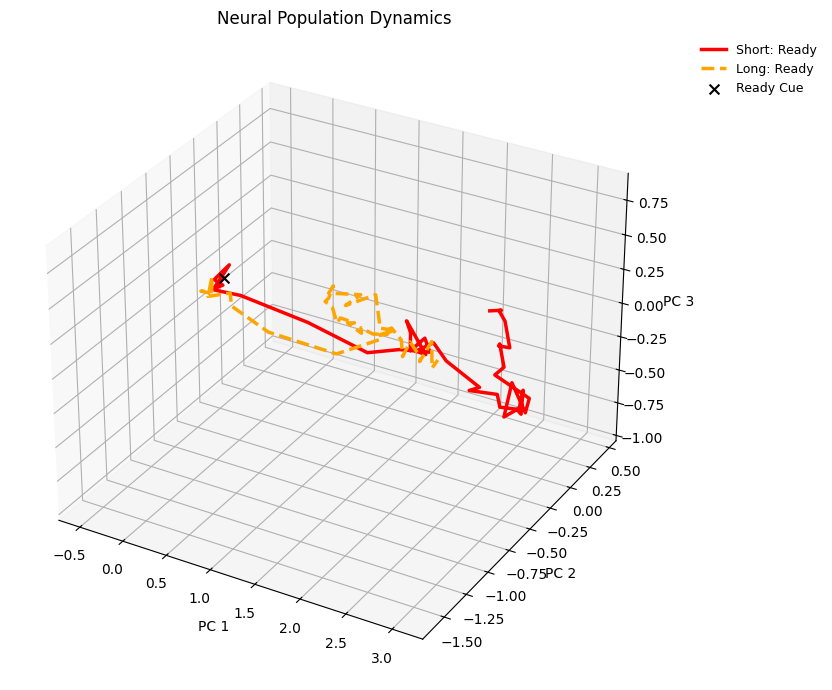

In [41]:
# 1. Define trajectories for the Ready Cue only
# We keep the lists containing only one element so the loop works perfectly
trajs_short = [ready_short]
trajs_long = [ready_long]
labels = ['Ready']

# Use your defined styles (index 0 corresponds to Ready)
short_styles = [('red', '-')] 
long_styles = [('orange', '--')]

# 2. Plotting
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot Short (Solid line for Ready)
for i in range(len(trajs_short)):
    ax.plot(trajs_short[i][:,0], trajs_short[i][:,1], trajs_short[i][:,2], 
            color=short_styles[i][0], linestyle='-', linewidth=2.5, 
            label=f"Short: {labels[i]}")

# Plot Long (Dashed line for Ready)
for i in range(len(trajs_long)):
    ax.plot(trajs_long[i][:,0], trajs_long[i][:,1], trajs_long[i][:,2], 
            color=long_styles[i][0], linestyle='--', linewidth=2.5, 
            label=f"Long: {labels[i]}")
    
ax.scatter(short_traj[0,0], short_traj[0,1], short_traj[0,2], 
           color='k', marker='x', s=50, label='Ready Cue')

# 3. Final Polish
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2'); ax.set_zlabel('PC 3')
ax.set_title('Neural Population Dynamics')


# Legend and View
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

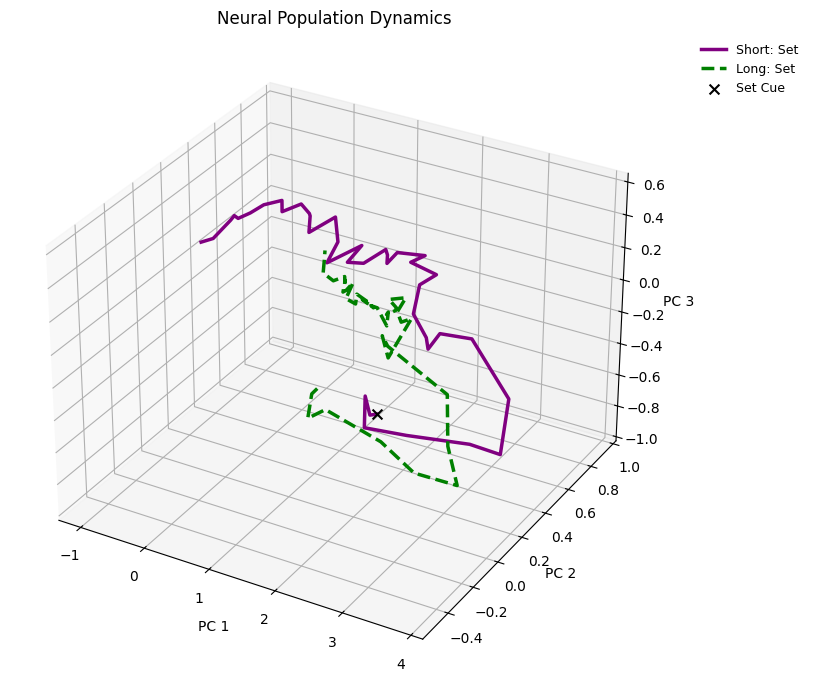

In [42]:
trajs_short = [set_short]
trajs_long = [set_long]
labels = ['Set']

# Use your defined styles (index 0 corresponds to Set)
# I have kept the colors/styles consistent with your previous multi-phase plot
short_styles = [('purple', '-')] 
long_styles = [('green', '--')]

# 2. Plotting
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot Short (Solid line for Set)
for i in range(len(trajs_short)):
    ax.plot(trajs_short[i][:,0], trajs_short[i][:,1], trajs_short[i][:,2], 
            color=short_styles[i][0], linestyle='-', linewidth=2.5, 
            label=f"Short: {labels[i]}")

# Plot Long (Dashed line for Set)
for i in range(len(trajs_long)):
    ax.plot(trajs_long[i][:,0], trajs_long[i][:,1], trajs_long[i][:,2], 
            color=long_styles[i][0], linestyle='--', linewidth=2.5, 
            label=f"Long: {labels[i]}")

# Add marker for the Set Cue onset
ax.scatter(set_short[0,0], set_short[0,1], set_short[0,2], 
           color='k', marker='x', s=50, label='Set Cue')

# 3. Final Polish
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2'); ax.set_zlabel('PC 3')
ax.set_title('Neural Population Dynamics')
# Legend and View
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

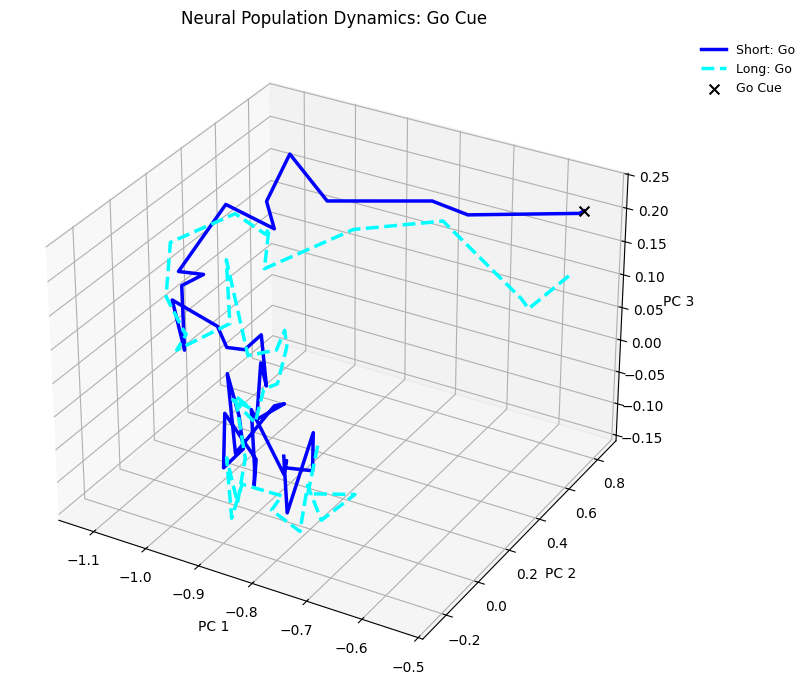

In [43]:
# 1. Define trajectories for the Go Cue only
trajs_short = [go_short]
trajs_long = [go_long]
labels = ['Go']

# Consistent styling
short_styles = [('blue', '-')] 
long_styles = [('cyan', '--')]

# 2. Plotting
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot Short (Solid line for Go)
for i in range(len(trajs_short)):
    ax.plot(trajs_short[i][:,0], trajs_short[i][:,1], trajs_short[i][:,2], 
            color=short_styles[i][0], linestyle='-', linewidth=2.5, 
            label=f"Short: {labels[i]}")

# Plot Long (Dashed line for Go)
for i in range(len(trajs_long)):
    ax.plot(trajs_long[i][:,0], trajs_long[i][:,1], trajs_long[i][:,2], 
            color=long_styles[i][0], linestyle='--', linewidth=2.5, 
            label=f"Long: {labels[i]}")

# Add marker for the Go Cue onset
ax.scatter(go_short[0,0], go_short[0,1], go_short[0,2], 
           color='k', marker='x', s=50, label='Go Cue')

# 3. Final Polish
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Population Dynamics: Go Cue')

# Legend and View
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()